# 07 — 2026 event study: did the crude spike behave differently?

`05_asymmetry.ipynb` found that retail prices respond faster to crude price increases than to decreases, based on the full 2010–2026 sample.

The 2026 episode was much larger than a typical weekly move. Crude prices rose sharply over several weeks and then gave back most of the increase, creating the largest complete rise-and-fall episode in the sample.

This notebook asks whether the up-versus-down response was different during that episode. We mark the 18 retail weeks from `2026-03-09` to `2026-07-06` and add event interactions to the same up/down distributed-lag model used in `05`.

The event coefficients measure how the 2026 response differed from the normal response estimated from the rest of the sample. Because the retail response can lag the crude move, the event marker is attached to the crude shock rather than only to the week in which the retail response appears.

In [1]:
import contextlib
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.asymmetry import DEFAULT_HAC_MAXLAGS, fit_distributed_lag
from src.event_study import (
    build_event_interaction_design,
    cumulative_passthrough_by_regime,
    run_event_study,
    test_event_asymmetry_change,
    test_event_interaction_joint,
)
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, load_series

WHOLESALE_SERIES_ID = "WGASUSGULF"

retail = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_crude = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
wholesale = load_series(PROCESSED_DIR / "spot.csv", WHOLESALE_SERIES_ID, "weekly-fri")

K = 4  # crude → retail primary spec, chosen in 04_lag_structure.ipynb §5 and used throughout 05/06

PRIMARY_START, PRIMARY_END = "2026-03-09", "2026-07-06"
COMPARISON_START, COMPARISON_END = "2022-03-07", "2022-06-13"

COLOR_UP = "#eb6834"
COLOR_DOWN = "#2a78d6"
COLOR_RETAIL = "#1baf7a"
COLOR_CRUDE = "#4a3aa7"
COLOR_WHOLESALE = "#c98a1f"
COLOR_PRIMARY_WINDOW = "#eb6834"
COLOR_COMPARISON_WINDOW = "#8a887c"

@contextlib.contextmanager
def _quiet():
    """build_design_matrix and build_event_interaction_design print sample attrition, which
    reads fine when called once (05, 06) but repeats four times here. Suppressed locally
    rather than changing those functions -- 05 and 06 have committed outputs including those
    lines."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield

sd_dcrude = weekly_crude["value"].diff().std()
print(f"full-sample sd of weekly Δcrude: {sd_dcrude:.4f} $/gal")

full-sample sd of weekly Δcrude: 0.0723 $/gal


## 1. The 2026 episode in historical context

Three charts show crude, retail, and wholesale prices in \$/gal on their respective weekly dates. The 2022 and 2026 episodes are highlighted. §7 uses 2022 and 2020 as comparison windows to see how the 2026 result compares with other large crude-price movements.

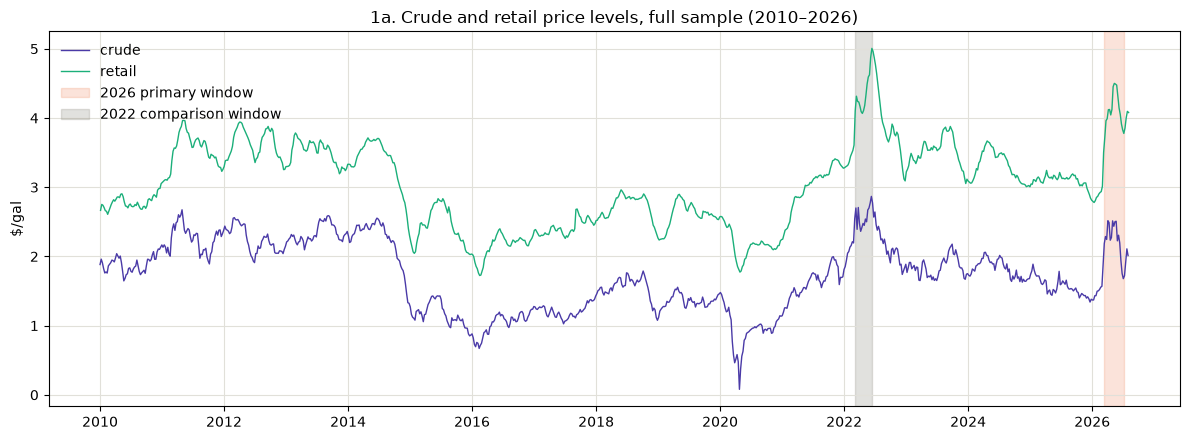

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(weekly_crude["date"], weekly_crude["value"], color=COLOR_CRUDE, linewidth=1.0, label="crude")
ax.plot(retail["date"], retail["value"], color=COLOR_RETAIL, linewidth=1.0, label="retail")

ax.axvspan(pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END), color=COLOR_PRIMARY_WINDOW, alpha=0.18, label="2026 primary window")
ax.axvspan(pd.Timestamp(COMPARISON_START), pd.Timestamp(COMPARISON_END), color=COLOR_COMPARISON_WINDOW, alpha=0.25, label="2022 comparison window")

ax.set_ylabel("$/gal")
ax.set_title("1a. Crude and retail price levels, full sample (2010–2026)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

2026 is unusually large relative to the rest of the sample. §2a quantifies the size of the episode.

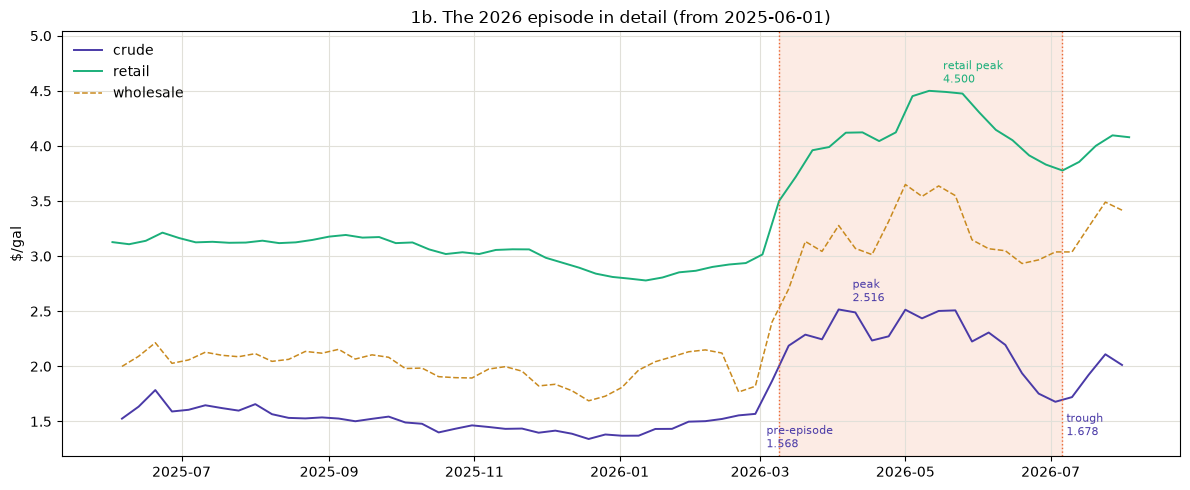

In [3]:
zoom_start = pd.Timestamp("2025-06-01")
crude_zoom = weekly_crude[weekly_crude["date"] >= zoom_start]
retail_zoom = retail[retail["date"] >= zoom_start]
wholesale_zoom = wholesale[wholesale["date"] >= zoom_start]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(crude_zoom["date"], crude_zoom["value"], color=COLOR_CRUDE, linewidth=1.4, label="crude")
ax.plot(retail_zoom["date"], retail_zoom["value"], color=COLOR_RETAIL, linewidth=1.4, label="retail")
ax.plot(wholesale_zoom["date"], wholesale_zoom["value"], color=COLOR_WHOLESALE, linewidth=1.1, linestyle="--", label="wholesale")

ax.axvspan(pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END), color=COLOR_PRIMARY_WINDOW, alpha=0.13)
for boundary in (pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END)):
    ax.axvline(boundary, color=COLOR_PRIMARY_WINDOW, linewidth=1, linestyle=":")

ax.set_ylim(top=max(crude_zoom["value"].max(), retail_zoom["value"].max(), wholesale_zoom["value"].max()) * 1.12)

annotations = [
    ("2026-02-27", 1.568, "pre-episode\n1.568", (8, -24), COLOR_CRUDE),
    ("2026-04-03", 2.516, "peak\n2.516", (10, 6), COLOR_CRUDE),
    ("2026-07-03", 1.678, "trough\n1.678", (8, -24), COLOR_CRUDE),
    ("2026-05-11", 4.500, "retail peak\n4.500", (10, 6), COLOR_RETAIL),
]
for date, value, text, offset, color in annotations:
    ax.annotate(text, xy=(pd.Timestamp(date), value), xytext=offset, textcoords="offset points", color=color, fontsize=8, ha="left")

ax.set_ylabel("$/gal")
ax.set_title("1b. The 2026 episode in detail (from 2025-06-01)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

Retail does not fully mirror the crude-price swing within the same weeks. In `05`, cumulative retail pass-through was about 60–70% in the first week and approached full pass-through by about the fourth week.

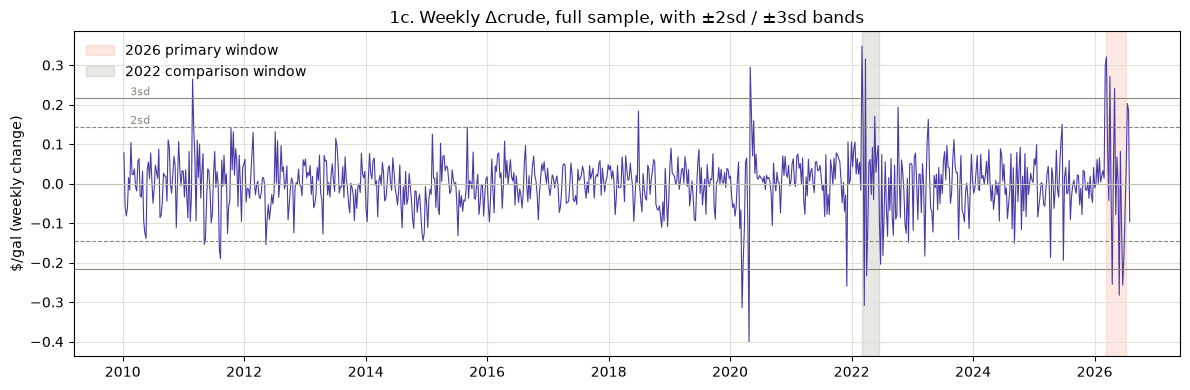

In [4]:
d_crude_full = weekly_crude["value"].diff()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_crude["date"], d_crude_full, color=COLOR_CRUDE, linewidth=0.8)
ax.axhline(0, color="#c3c2b7", linewidth=0.8)

for mult, ls in [(2, "--"), (3, "-")]:
    ax.axhline(mult * sd_dcrude, color="#8a887c", linewidth=0.8, linestyle=ls)
    ax.axhline(-mult * sd_dcrude, color="#8a887c", linewidth=0.8, linestyle=ls)
label_x = weekly_crude["date"].iloc[3]
ax.text(label_x, 2 * sd_dcrude, " 2sd", fontsize=8, color="#8a887c", va="bottom")
ax.text(label_x, 3 * sd_dcrude, " 3sd", fontsize=8, color="#8a887c", va="bottom")

ax.axvspan(pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END), color=COLOR_PRIMARY_WINDOW, alpha=0.15, label="2026 primary window")
ax.axvspan(pd.Timestamp(COMPARISON_START), pd.Timestamp(COMPARISON_END), color=COLOR_COMPARISON_WINDOW, alpha=0.2, label="2022 comparison window")

ax.set_title("1c. Weekly Δcrude, full sample, with ±2sd / ±3sd bands")
ax.set_ylabel("$/gal (weekly change)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
fig.savefig(REPO_ROOT / "assets" / "07_crude_moves_sd_bands.png", dpi=110, bbox_inches="tight")
plt.show()

The 2026 window contains more weeks with crude moves beyond 3 standard deviations than the 2022 or 2020 comparison windows. The single largest weekly move in the sample is still the 2020 crash. §2a counts these extreme weeks.

## 2. Defining the event window

**2a.** We identify all weeks with `|Δcrude| > 3sd` and group nearby weeks into episodes. A new episode starts when the gap from the previous >3sd week exceeds 60 days.

The 60-day cutoff separates the observed clusters: the widest gap within an episode is 28 days (2026), while the narrowest gap between separate episodes is 91 days (an isolated week in December 2021, and the March 2022 cluster).

In [5]:
d = weekly_crude["value"].diff()
sd_units = d / sd_dcrude

beyond3 = weekly_crude.loc[sd_units.abs() > 3, ["date", "value"]].copy()
beyond3["d_crude"] = d[sd_units.abs() > 3]
beyond3["sd_units"] = sd_units[sd_units.abs() > 3]
beyond3 = beyond3.sort_values("date").reset_index(drop=True)

gap = beyond3["date"].diff()
new_episode = gap.isna() | (gap > pd.Timedelta(days=60))
episode_num = new_episode.cumsum()
beyond3["episode"] = episode_num.map(beyond3.groupby(episode_num)["date"].min().dt.year.astype(str))

print(beyond3.groupby("episode").size().rename("n_weeks_beyond_3sd"))
print()
beyond3.round({"value": 4, "d_crude": 4, "sd_units": 4})

episode
2011    1
2020    3
2021    1
2022    4
2026    7
Name: n_weeks_beyond_3sd, dtype: int64



,date,value,d_crude,sd_units,episode
0,2011-02-25,2.2681,0.2650,3.6676,2011
1,2020-03-13,0.7712,-0.3138,-4.3431,2020
2,2020-04-24,0.0790,-0.4000,-5.5360,2020
3,2020-05-01,0.3740,0.2950,4.0828,2020
4,2021-12-03,1.5926,-0.2595,-3.5918,2021
5,2022-03-04,2.5429,0.3481,4.8177,2022
6,2022-03-18,2.3912,-0.3086,-4.2706,2022
7,2022-03-25,2.7069,0.3157,4.3695,2022
8,2022-04-01,2.4736,-0.2333,-3.2293,2022
9,2026-03-06,1.8660,0.2976,4.1191,2026


**2b.** Candidate event windows are compared by number of weeks, number of up/down weeks, and average crude-move size.

In [6]:
def candidate_window_stats(retail_start, retail_end) -> dict:
    crude_start = pd.Timestamp(retail_start) - pd.Timedelta(days=3)
    crude_end = pd.Timestamp(retail_end) - pd.Timedelta(days=3)
    window = weekly_crude[(weekly_crude["date"] >= crude_start) & (weekly_crude["date"] <= crude_end)]
    window_d = d.loc[window.index]
    return {
        "n_weeks": len(window),
        "n_up": int((window_d > 0).sum()),
        "n_down": int((window_d < 0).sum()),
        "mean_abs_dcrude": window_d.abs().mean(),
        "mean_abs_in_sd_units": window_d.abs().mean() / sd_dcrude,
    }


candidates = [
    ("rise-only", "2026-03-09", "2026-04-06"),
    ("round-trip (chosen)", "2026-03-09", "2026-07-06"),
    ("through-end-of-data", "2026-03-09", "2026-08-03"),
    ("2022 comparison", "2022-03-07", "2022-06-13"),
]

candidate_table = pd.DataFrame(
    [{"candidate": name, "retail_start": start, "retail_end": end, **candidate_window_stats(start, end)} for name, start, end in candidates]
)
candidate_table.round(4)

,candidate,retail_start,retail_end,n_weeks,n_up,n_down,mean_abs_dcrude,mean_abs_in_sd_units
0,rise-only,2026-03-09,2026-04-06,5,4,1,0.2065,2.8576
1,round-trip (chosen),2026-03-09,2026-07-06,18,9,9,0.1520,2.1040
2,through-end-of-data,2026-03-09,2026-08-03,22,12,10,0.1484,2.0535
3,2022 comparison,2022-03-07,2022-06-13,15,10,5,0.1410,1.9519


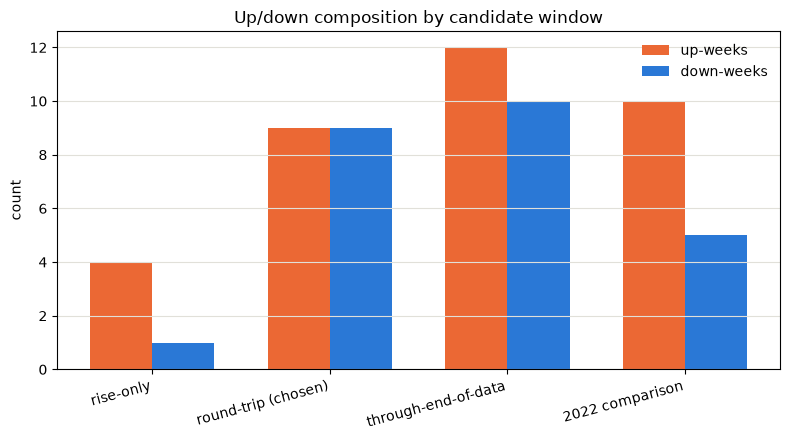

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(candidate_table))
width = 0.35

ax.bar(x - width / 2, candidate_table["n_up"], width, color=COLOR_UP, label="up-weeks")
ax.bar(x + width / 2, candidate_table["n_down"], width, color=COLOR_DOWN, label="down-weeks")

ax.set_xticks(x)
ax.set_xticklabels(candidate_table["candidate"], rotation=15, ha="right")
ax.set_ylabel("count")
ax.set_title("Up/down composition by candidate window")
ax.grid(True, axis="y", color="#e1e0d9")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**2c.** Chosen window: retail Mondays `2026-03-09` to `2026-07-06`, 18 weeks, with 9 up-weeks and 9 down-weeks.

2026 is the only large episode in the sample that contains both a large rise and a large reversal. Crude rose from 1.568 before the window to 2.516 at the peak, then fell to 1.678 by the end of the window, an 88% retracement. Retail prices also rose and then fell, but retraced about half of their increase, from a peak of 4.500 to 3.777.

A separate crude increase begins in mid-July, after the chosen window, so it is not included.

The comparison windows do not contain a complete round trip. Crude rises throughout the 2022 window, while the 2020 crash is only partly reversed by the end of its window.

2026 also has the most >3sd weeks of the three episodes (7 versus 4 in 2022 and 3 in 2020) and is the only window with an even 9/9 split between up and down weeks.

The balanced split is useful for the event study because the comparison requires estimating both up- and down-responses. The alternative windows considered above either contain very few down-weeks or end at a less natural point in the episode.

## 3. The interaction design

`build_event_interaction_design` extends the up/down distributed-lag model from `05` by adding event interactions. The regression estimates the normal response and the additional 2026 response in the same model.

Two specifications are used.

**Spec A** interacts lags 0–4, giving ten 2026-specific coefficients: one up and one down coefficient at each lag. This allows the event effect to appear at any lag included in the primary model.

**Spec B** interacts only lags 0–1, giving four event-specific coefficients. `05` found that the up-versus-down difference is concentrated in these first two weeks, so this specification focuses the event test on that part of the response.

Spec A is more flexible but estimates more coefficients from the same 18 event weeks. Spec B estimates fewer coefficients and is therefore more precise, but it cannot detect an event-specific change that occurs only at lags 2–4.

The lag restriction in Spec B was chosen from `05` before looking at the event-study results. It is therefore a specification choice based on the earlier model, not on the 2026 results.

In [8]:
with _quiet():
    design_a = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PRIMARY_START, event_end=PRIMARY_END, interact_lags=list(range(K + 1))
    )
    design_b = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PRIMARY_START, event_end=PRIMARY_END, interact_lags=[0, 1]
    )

In [9]:
# Comparison-window design matrices are computed here, not deferred to §8, so this table can report both
# windows' condition numbers together -- the comparison-window test itself still doesn't run until §8.
with _quiet():
    design_a_comparison = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=COMPARISON_START, event_end=COMPARISON_END, interact_lags=list(range(K + 1))
    )
    design_b_comparison = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=COMPARISON_START, event_end=COMPARISON_END, interact_lags=[0, 1]
    )

In [10]:
def condition_number(design: pd.DataFrame) -> float:
    regressor_columns = [c for c in design.columns if c not in ("date", "d_retail")]
    X = np.column_stack([np.ones(len(design)), design[regressor_columns].to_numpy()])
    return float(np.linalg.cond(X))


In [11]:
def summarize_design(design: pd.DataFrame, window: str, spec: str) -> dict:
    n_up = int(((design["event"] == 1) & (design["d_up_lag0"] > 0)).sum())
    n_down = int(((design["event"] == 1) & (design["d_down_lag0"] < 0)).sum())
    return {
        "window": window,
        "spec": spec,
        "n_rows": len(design),
        "event_rows": int(design["event"].sum()),
        "up": n_up,
        "down": n_down,
        "condition_number": condition_number(design),
    }


summary_table = pd.DataFrame(
    [
        summarize_design(design_a, "2026", "A"),
        summarize_design(design_b, "2026", "B"),
        summarize_design(design_a_comparison, "2022 comparison", "A"),
        summarize_design(design_b_comparison, "2022 comparison", "B"),
    ]
)
summary_table.round(1)

,window,spec,n_rows,event_rows,up,down,condition_number
0,2026,A,861,18,9,9,167.4
1,2026,B,861,18,9,9,127.5
2,2022 comparison,A,861,15,10,5,330.3
3,2022 comparison,B,861,15,10,5,131.6


Spec A estimates ten event-specific coefficients from only 18 event weeks, so the individual coefficients are imprecise. The joint test in §5 is therefore more informative than any single event coefficient.

## 4. The fitted models

Both specifications are fitted to 861 observations, using the same `maxlags=6` HAC window as in `05` and `06`:

```
Δretail = α + γ·event + Σβ⁺·d_up_lag{k} + Σδ⁺·d_up_lag{k}_event
                      + Σβ⁻·d_down_lag{k} + Σδ⁻·d_down_lag{k}_event + ε
```

The non-event coefficients estimate the normal up- and down-responses using the rest of the sample. The event interaction coefficients measure the additional response during the 2026 window.

Fitting both parts together provides a direct comparison between the event period and the normal response in the same model.

In [12]:
res_a = fit_distributed_lag(design_a, maxlags=DEFAULT_HAC_MAXLAGS)
res_b = fit_distributed_lag(design_b, maxlags=DEFAULT_HAC_MAXLAGS)

assert "event" in res_a.params.index and "event" in res_b.params.index

print(res_b.summary())

                            OLS Regression Results                            
Dep. Variable:               d_retail   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     28.35
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           8.71e-65
Time:                        18:09:00   Log-Likelihood:                 1500.5
No. Observations:                 861   AIC:                            -2969.
Df Residuals:                     845   BIC:                            -2893.
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0028      0.00

The event-specific standard errors are much larger than the standard coefficient errors because they are estimated from only 18 event weeks. This is especially pronounced in Spec A, which estimates ten event-specific coefficients.

For that reason, individual event coefficients should be treated as follow-up detail. The joint test in §5 is the main test of whether the event response differs from normal.

In [13]:
print(res_a.summary())

                            OLS Regression Results                            
Dep. Variable:               d_retail   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     62.96
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          3.19e-156
Time:                        18:09:00   Log-Likelihood:                 1514.4
No. Observations:                 861   AIC:                            -2985.
Df Residuals:                     839   BIC:                            -2880.
Df Model:                          21                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0028      0.00

How much noisier the 2026-specific estimates are than the normal ones, per lag:

In [14]:
def se_ratio_table(res, interact_lags, spec_label):
    rows = []
    for k in interact_lags:
        for direction in ("up", "down"):
            beta_name = f"d_{direction}_lag{k}"
            delta_name = f"d_{direction}_lag{k}_event"
            rows.append(
                {
                    "spec": spec_label,
                    "lag": k,
                    "direction": direction,
                    "beta_se": res.bse[beta_name],
                    "delta_se": res.bse[delta_name],
                    "ratio": res.bse[delta_name] / res.bse[beta_name],
                }
            )
    return pd.DataFrame(rows)


se_table = pd.concat([se_ratio_table(res_a, list(range(K + 1)), "A"), se_ratio_table(res_b, [0, 1], "B")], ignore_index=True)
se_table.round(3)

,spec,lag,direction,beta_se,delta_se,ratio
0,A,0,up,0.087,0.304,3.473
1,A,0,down,0.049,0.456,9.354
2,A,1,up,0.036,0.343,9.627
3,A,1,down,0.039,0.243,6.149
4,A,2,up,0.043,0.092,2.150
5,A,2,down,0.035,0.149,4.298
6,A,3,up,0.047,0.287,6.106
7,A,3,down,0.032,0.113,3.535
8,A,4,up,0.040,0.097,2.414
9,A,4,down,0.044,0.180,4.048


The event-specific standard errors are 2–10 times larger than the corresponding normal-response standard errors. This reflects the much smaller number of event weeks: about 840 non-event weeks versus 18 event weeks.

Spec B is more precise because it estimates four event-specific coefficients instead of ten.

The normal-response coefficients are also close to the estimates from `05`: the same-week up-response is 0.623–0.636 here versus 0.696 in `05`, while the down-response is about 0.260 versus 0.263. The small difference is expected because the 18 event weeks receive separate coefficients in this model.

## 5. Did the 2026 response differ from normal?

Two tests answer different questions.

The **joint test** asks whether the 2026-specific interaction coefficients are all zero. A significant result means that at least some part of the event response differs from the normal response.

The **asymmetry-change test** asks the question of interest here: did the difference between the up-response and down-response change during 2026?

In [15]:
def t_stat(estimate, se):
    return estimate / se if se else float("nan")


def display_with_pvalue(df, col="p_value", threshold=0.0001):
    """round(4) turns any p-value smaller than 0.0001 into a misleading literal 0.0000.
    Anything that small is shown as '<0.0001' instead of being rounded away."""
    out = df.round(4).copy()
    out[col] = df[col].apply(lambda p: (f"<{threshold}" if pd.notna(p) and p < threshold else (f"{p:.4f}" if pd.notna(p) else "")))
    return out


test_rows = []
for spec_label, res in [("A", res_a), ("B", res_b)]:
    joint = test_event_interaction_joint(res)
    test_rows.append(
        {
            "spec": spec_label,
            "test": "joint F",
            "statistic": joint["f_stat"],
            "p_value": joint["p_value"],
            "estimate": float("nan"),
            "ci_lo": float("nan"),
            "ci_hi": float("nan"),
        }
    )
    asym = test_event_asymmetry_change(res)
    test_rows.append(
        {
            "spec": spec_label,
            "test": "asymmetry change",
            "statistic": t_stat(asym["estimate"], asym["se"]),
            "p_value": asym["p_value"],
            "estimate": asym["estimate"],
            "ci_lo": asym["ci_lo"],
            "ci_hi": asym["ci_hi"],
        }
    )

test_table = pd.DataFrame(test_rows)
display_with_pvalue(test_table)

,spec,test,statistic,p_value,estimate,ci_lo,ci_hi
0,A,joint F,12.4572,<0.0001,NaN,NaN,NaN
1,A,asymmetry change,0.1721,0.8633,0.2795,-2.9030,3.4620
2,B,joint F,2.8687,0.0223,NaN,NaN,NaN
3,B,asymmetry change,0.2428,0.8081,0.1614,-1.1416,1.4645


The up-versus-down gap does not show a detectable change during the 2026 window. The asymmetry-change estimate is 0.280 for Spec A (p = 0.863) and 0.161 for Spec B (p = 0.808).

The joint test gives a different result: it rejects the hypothesis that all event-specific coefficients are zero (p < 0.0001 for Spec A and p = 0.022 for Spec B). This means that some part of the 2026 response differs from the normal response, but it does not show that the up-versus-down asymmetry changed.

The individual event coefficients are therefore examined only as follow-up detail.

In [16]:
def delta_table(res, interact_lags, spec_label):
    rows = []
    for k in interact_lags:
        for direction in ("up", "down"):
            name = f"d_{direction}_lag{k}_event"
            rows.append({"spec": spec_label, "lag": k, "direction": direction, "coef": res.params[name], "se": res.bse[name], "p_value": res.pvalues[name]})
    return pd.DataFrame(rows)


posthoc_table = pd.concat([delta_table(res_a, list(range(K + 1)), "A"), delta_table(res_b, [0, 1], "B")], ignore_index=True)
display_with_pvalue(posthoc_table)

,spec,lag,direction,coef,se,p_value
0,A,0,up,0.3600,0.3036,0.2357
1,A,0,down,0.2551,0.4556,0.5755
2,A,1,up,-0.1247,0.3429,0.7161
3,A,1,down,0.0055,0.2425,0.9818
4,A,2,up,0.0521,0.0923,0.5724
5,A,2,down,-0.3619,0.1486,0.0149
6,A,3,up,-0.0705,0.2870,0.8060
7,A,3,down,-0.2353,0.1128,0.0371
8,A,4,up,-0.2617,0.0969,0.0069
9,A,4,down,0.0123,0.1798,0.9455


Spec A has three individual coefficients with p < 0.05: the lag-2 down, lag-3 down, and lag-4 up interactions. Their signs do not form a consistent pattern across neighbouring lags.

Spec B has no individual coefficient with p < 0.05.

The joint test therefore indicates that some event-specific coefficients differ from zero, but the individual results do not provide a clear or consistent pattern that would explain the rejection. In particular, neither specification shows evidence that the up-versus-down gap changed during 2026.

## 6. Cumulative pass-through, normal versus event

The cumulative responses provide a visual check of the asymmetry-change result from §5. If the event period had a larger up-versus-down gap than normal, the event lines would separate in the direction of greater asymmetry. If the gap became smaller, the lines would move closer together.

The confidence bands overlap throughout the horizon in both specifications, consistent with the non-significant asymmetry-change tests.

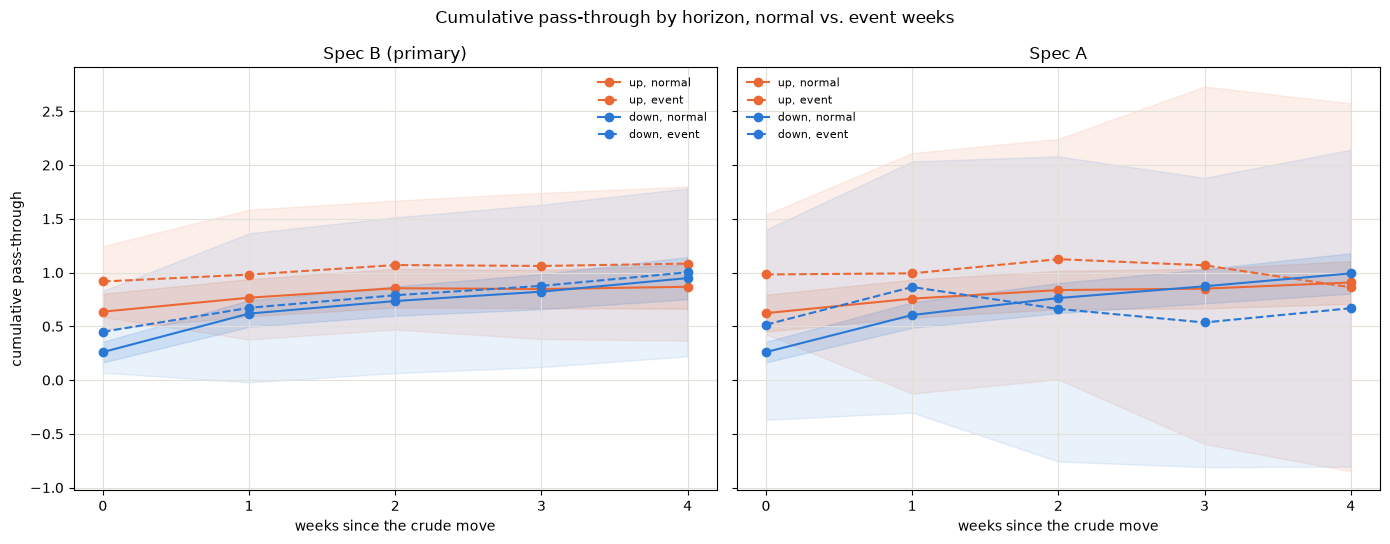

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, res, title in zip(axes, [res_b, res_a], ["Spec B (primary)", "Spec A"]):
    cum = cumulative_passthrough_by_regime(res, K)

    ax.plot(cum["horizon"], cum["cum_up_normal"], color=COLOR_UP, linestyle="-", marker="o", label="up, normal")
    ax.fill_between(cum["horizon"], cum["cum_up_normal_lo"], cum["cum_up_normal_hi"], color=COLOR_UP, alpha=0.15)
    ax.plot(cum["horizon"], cum["cum_up_event"], color=COLOR_UP, linestyle="--", marker="o", label="up, event")
    ax.fill_between(cum["horizon"], cum["cum_up_event_lo"], cum["cum_up_event_hi"], color=COLOR_UP, alpha=0.1)

    ax.plot(cum["horizon"], cum["cum_down_normal"], color=COLOR_DOWN, linestyle="-", marker="o", label="down, normal")
    ax.fill_between(cum["horizon"], cum["cum_down_normal_lo"], cum["cum_down_normal_hi"], color=COLOR_DOWN, alpha=0.15)
    ax.plot(cum["horizon"], cum["cum_down_event"], color=COLOR_DOWN, linestyle="--", marker="o", label="down, event")
    ax.fill_between(cum["horizon"], cum["cum_down_event_lo"], cum["cum_down_event_hi"], color=COLOR_DOWN, alpha=0.1)

    ax.set_title(title)
    ax.set_xlabel("weeks since the crude move")
    ax.set_xticks(cum["horizon"])
    ax.grid(True, color="#e1e0d9")
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("cumulative pass-through")
fig.suptitle("Cumulative pass-through by horizon, normal vs. event weeks")
plt.tight_layout()
plt.show()

The event and normal confidence bands overlap throughout the horizon. In Spec B, the lines coincide after h = 1 because no event-specific coefficients are included beyond lag 1.

## 7. Comparison windows

The 2026 episode was unusually large, so the result could reflect the size or disruption of a large crude-price move rather than something specific to 2026.

We therefore rerun the same event-study tests on two other large crude-price episodes: 2022 and 2020. These windows are comparison cases, not additional primary events.

Both windows are chosen the same way 2026's was, bracketing a cluster of >3sd weeks.

| window | dates | reason |
|---|---|---|
| 2022 (primary) | `2022-03-07`-`2022-06-13` | Closest structural twin: geopolitical supply shock, 4 weeks beyond 3sd, moves both directions. |
| 2020 (secondary) | `2020-03-16`-`2020-06-15` | Includes the sample's single most extreme week (2020-04-24, -5.54sd). Kept in on purpose, as an upper bound on how large an effect can look in a disrupted market. But COVID also collapsed retail demand here, so a result may reflect that instead of pricing behavior. |

2011 excluded: one week beyond 3sd, too small to form a window.

Both comparison windows contain fewer down-weeks than 2026: 5 versus 9. Their down-response estimates are therefore less precise.

A non-significant result in these windows should not be interpreted as proof that nothing changed. The comparison windows have limited power to detect a change in the down-response.

2026 remains the only episode in the sample with a large rise and a large reversal within the same window.

In [18]:
COMPARISON_2020_START, COMPARISON_2020_END = "2020-03-16", "2020-06-15"

window_order = ["2026", "2022", "2020"]
windows = [
    ("2026", PRIMARY_START, PRIMARY_END),
    ("2022", COMPARISON_START, COMPARISON_END),
    ("2020", COMPARISON_2020_START, COMPARISON_2020_END),
]
specs = [("A", list(range(K + 1))), ("B", [0, 1])]

with _quiet():
    event_study_results = {
        (window_name, spec_name): run_event_study(
            retail,
            weekly_crude,
            K=K,
            event_start=start,
            event_end=end,
            label=f"{window_name}-{spec_name}",
            interact_lags=lags,
            maxlags=DEFAULT_HAC_MAXLAGS,
        )
        for window_name, start, end in windows
        for spec_name, lags in specs
    }

**7a.** Basic stats for each episode's crude moves, before any model is fit. `n_up`/`n_down`
here match §3/§4's table for 2026.

In [19]:
def episode_window_stats(retail_start, retail_end, shape):
    crude_start = pd.Timestamp(retail_start) - pd.Timedelta(days=3)
    crude_end = pd.Timestamp(retail_end) - pd.Timedelta(days=3)
    window = weekly_crude[(weekly_crude["date"] >= crude_start) & (weekly_crude["date"] <= crude_end)]
    window_d = d.loc[window.index]
    window_sd = sd_units.loc[window.index]
    return {
        "n_weeks": len(window),
        "n_up": int((window_d > 0).sum()),
        "n_down": int((window_d < 0).sum()),
        "mean_abs_dcrude_sd": window_d.abs().mean() / sd_dcrude,
        "max_abs_dcrude_sd": window_sd.abs().max(),
        "n_weeks_beyond_3sd": int((window_sd.abs() > 3).sum()),
        "shape": shape,
    }


episode_stats = {
    "2026": episode_window_stats(PRIMARY_START, PRIMARY_END, "round trip"),
    "2022": episode_window_stats(COMPARISON_START, COMPARISON_END, "rise, no reversal"),
    "2020": episode_window_stats(COMPARISON_2020_START, COMPARISON_2020_END, "crash, partial recovery"),
}

episode_table = pd.DataFrame([{"window": name, **stats} for name, stats in episode_stats.items()])
episode_table.round(3)

,window,n_weeks,n_up,n_down,mean_abs_dcrude_sd,max_abs_dcrude_sd,n_weeks_beyond_3sd,shape
0,2026,18,9,9,2.104,4.442,7,round trip
1,2022,15,10,5,1.952,4.818,4,"rise, no reversal"
2,2020,14,9,5,2.042,5.536,3,"crash, partial recovery"


**7b.** The main result: for each window, the extra up-response minus the extra down-response
(`sum(delta+) - sum(delta-)` in §4's equation), with its 95% confidence interval. One panel per
spec.

The down-response half of that number comes from far fewer weeks in the comparison windows than in 2026:
9 down-weeks for 2026, only 5 for 2022 and 5 for 2020. Fewer weeks means a less precise
down-response estimate, which widens the combined confidence interval and makes it more likely
to cross zero even if a real change exists. A null result in 2022 or 2020 is therefore weaker
evidence of "nothing changed" than a null result in 2026 would be.

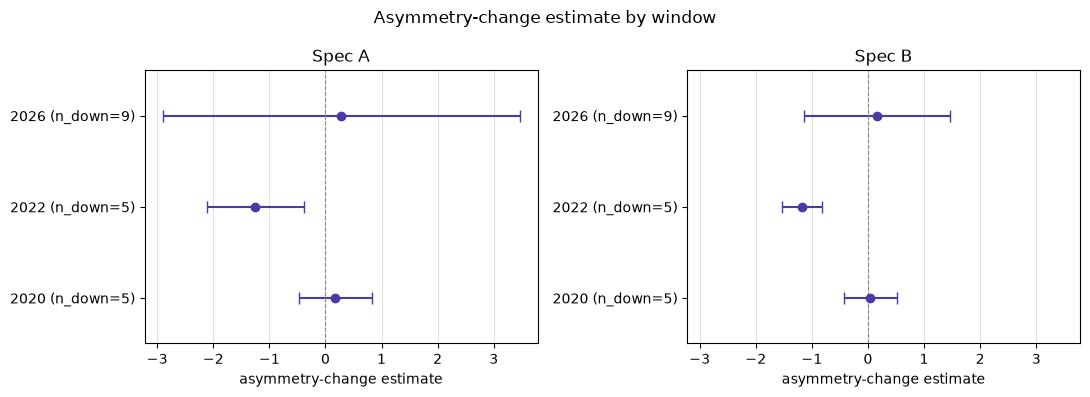

In [20]:
down_n = episode_table.set_index("window")["n_down"].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
fig.suptitle("Asymmetry-change estimate by window")

for ax, spec_name in zip(axes, ["A", "B"]):
    for y, wname in enumerate(window_order):
        result = event_study_results[(wname, spec_name)]["asymmetry_change"]
        ax.errorbar(
            result["estimate"],
            y,
            xerr=[[result["estimate"] - result["ci_lo"]], [result["ci_hi"] - result["estimate"]]],
            fmt="o",
            color=COLOR_CRUDE,
            capsize=4,
        )
    ax.axvline(0, color="#8a887c", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(window_order)))
    ax.set_yticklabels([f"{w} (n_down={down_n[w]})" for w in window_order])
    ax.set_ylim(-0.5, len(window_order) - 0.5)
    ax.invert_yaxis()
    ax.set_title(f"Spec {spec_name}")
    ax.set_xlabel("asymmetry-change estimate")
    ax.grid(True, axis="x", color="#e1e0d9")

fig.suptitle("Asymmetry-change estimate by window")
plt.tight_layout()
plt.show()

In [21]:
asymmetry_change_table = pd.DataFrame(
    [
        {"window": wname, "spec": sname, **event_study_results[(wname, sname)]["asymmetry_change"]}
        for wname in window_order
        for sname in ["A", "B"]
    ]
)[["window", "spec", "estimate", "se", "ci_lo", "ci_hi", "p_value"]]
display_with_pvalue(asymmetry_change_table)

,window,spec,estimate,se,ci_lo,ci_hi,p_value
0,2026,A,0.2795,1.6237,-2.9030,3.4620,0.8633
1,2026,B,0.1614,0.6648,-1.1416,1.4645,0.8081
2,2022,A,-1.2493,0.4403,-2.1123,-0.3864,0.0045
3,2022,B,-1.1752,0.1819,-1.5317,-0.8187,<0.0001
4,2020,A,0.1744,0.3308,-0.4740,0.8228,0.5980
5,2020,B,0.0429,0.2438,-0.4348,0.5207,0.8602


The 2022 confidence interval excludes zero in both specifications, while the 2026 and 2020 intervals include zero. In 2022, the estimated up-versus-down gap was smaller than normal.

This is a separate observation from the full-sample result in `05`: the 2022 window appears to have had a more symmetric response, but the result is exploratory because 2022 was a comparison window rather than the pre-specified event of interest. §7d checks whether the result is driven by individual coefficients or shows a more consistent pattern.

**7c.** If a window behaved exactly like a normal week, its extra coefficients would all be zero. This is the baseline tested by the joint test. Run separately for each window: are the event-specific coefficients jointly consistent with zero, or not?

In [22]:
joint_table = pd.DataFrame(
    [
        {
            "window": wname,
            "spec": sname,
            "f_stat": event_study_results[(wname, sname)]["joint"]["f_stat"],
            "p_value": event_study_results[(wname, sname)]["joint"]["p_value"],
        }
        for wname in window_order
        for sname in ["A", "B"]
    ]
)
display_with_pvalue(joint_table)

,window,spec,f_stat,p_value
0,2026,A,12.4572,<0.0001
1,2026,B,2.8687,0.0223
2,2022,A,12.9408,<0.0001
3,2022,B,14.8608,<0.0001
4,2020,A,10.7820,<0.0001
5,2020,B,8.3328,<0.0001


The joint test rejects the zero-event-effect hypothesis for all three windows in both specifications (p < 0.03 in every case).

This means that each window has at least some event-specific coefficients that differ from zero. It does not tell us whether those differences are related to the up-versus-down asymmetry, and it does not distinguish a common response to a large crude-price movement from a feature specific to a particular episode.

**7d.** §7c only tells us whether the event-specific coefficients are jointly different from zero. It does not show whether the individual coefficients form a clear pattern across lags and directions. Here we count the coefficients with p < 0.05 and examine their signs and locations.

This is most useful for interpreting the 2022 result. In §5, three of 2026's Spec A coefficients had p < 0.05 (lag 2 down, lag 3 down, and lag 4 up), but they were spread across different lags and directions and did not give a clear interpretation. We use the same check for 2022 and 2020 rather than treating individual significant coefficients as evidence on their own.

In [23]:
def delta_hits(res, lags):
    hits = []
    for k in lags:
        for direction in ("up", "down"):
            name = f"d_{direction}_lag{k}_event"
            if res.pvalues[name] < 0.05:
                p = res.pvalues[name]
                p_display = "<0.0001" if p < 0.0001 else round(p, 4)
                hits.append({"lag": k, "direction": direction, "coef": round(res.params[name], 4), "p_value": p_display})
    return hits


scatter_rows = []
hit_rows = []
for wname in window_order:
    for sname, lags in specs:
        res = event_study_results[(wname, sname)]["res"]
        hits = delta_hits(res, lags)
        scatter_rows.append({"window": wname, "spec": sname, "n_params": len(lags) * 2, "n_hits": len(hits)})
        for h in hits:
            hit_rows.append({"window": wname, "spec": sname, **h})

scatter_table = pd.DataFrame(scatter_rows)
scatter_table

,window,spec,n_params,n_hits
0,2026,A,10,3
1,2026,B,4,0
2,2022,A,10,3
3,2022,B,4,2
4,2020,A,10,5
5,2020,B,4,0


In [24]:
hits_table = pd.DataFrame(hit_rows, columns=["window", "spec", "lag", "direction", "coef", "p_value"])
hits_table.sort_values(by=["window", "spec", "lag", "direction"], ascending=[False, True, True, True]).reset_index(drop=True)

,window,spec,lag,direction,coef,p_value
0,2026,A,2,down,-0.3619,0.0149
1,2026,A,3,down,-0.2353,0.0371
2,2026,A,4,up,-0.2617,0.0069
3,2022,A,1,up,-0.2822,0.0005
4,2022,A,3,up,-0.5602,0.008
5,2022,A,4,up,-0.2118,0.0441
6,2022,B,1,down,0.7585,0.0002
7,2022,B,1,up,-0.3435,<0.0001
8,2020,A,0,down,-0.1962,0.0406
9,2020,A,0,up,-0.3174,0.0043


**7e.** Baseline check: compare the normal-response coefficients estimated within each event-study model with the original full-sample estimates from `05`.

In [25]:
baseline_rows = []
ref_up, ref_down = 0.6960, 0.2633  # 05's standalone K=4 estimate
for wname in window_order:
    for sname in ["A", "B"]:
        res = event_study_results[(wname, sname)]["res"]
        up = res.params["d_up_lag0"]
        down = res.params["d_down_lag0"]
        baseline_rows.append(
            {
                "window": wname,
                "spec": sname,
                "up_lag0": up,
                "delta_up": up - ref_up,
                "down_lag0": down,
                "delta_down": down - ref_down,
            }
        )

baseline_table = pd.DataFrame(baseline_rows)
baseline_table.round(4)

,window,spec,up_lag0,delta_up,down_lag0,delta_down
0,2026,A,0.6226,-0.0734,0.2603,-0.0030
1,2026,B,0.6363,-0.0597,0.2602,-0.0031
2,2022,A,0.6491,-0.0469,0.2579,-0.0054
3,2022,B,0.6483,-0.0477,0.2656,0.0023
4,2020,A,0.7000,0.0040,0.3021,0.0388
5,2020,B,0.6982,0.0022,0.3027,0.0394


Across the six window/specification combinations, the largest deviation from the `05` up- or down-response estimate is 0.073. The normal-response coefficients therefore remain close to the original estimates, suggesting that no single event window is driving the headline full-sample coefficients.

**7f.** The 2022 result in Spec B is checked for sensitivity to its largest crude move and to the fact that three event windows are being tested.

Spec B uses 15 event weeks in 2022, including only 5 down-weeks. The largest crude move occurs on `2022-03-07` (+0.35 \$/gal). We therefore refit the model after removing that week.

In [26]:
with _quiet():
    design_2022_b = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=COMPARISON_START, event_end=COMPARISON_END, interact_lags=[0, 1]
    )

event_rows_2022 = design_2022_b[design_2022_b["event"] == 1].copy()
event_rows_2022["abs_move"] = (event_rows_2022["d_up_lag0"] + event_rows_2022["d_down_lag0"]).abs()
largest_move_date = event_rows_2022.sort_values("abs_move", ascending=False)["date"].iloc[0]

asym_2022_b_full = event_study_results[("2022", "B")]["asymmetry_change"]

design_2022_b_trimmed = design_2022_b[design_2022_b["date"] != largest_move_date].reset_index(drop=True)
res_2022_b_trimmed = fit_distributed_lag(design_2022_b_trimmed, maxlags=DEFAULT_HAC_MAXLAGS)
asym_2022_b_trimmed = test_event_asymmetry_change(res_2022_b_trimmed)

influence_table = pd.DataFrame(
    [
        {"fit": "all 15 event weeks", **asym_2022_b_full},
        {"fit": f"{largest_move_date.date()} excluded", **asym_2022_b_trimmed},
    ]
)
display_with_pvalue(influence_table)

,fit,estimate,se,ci_lo,ci_hi,p_value
0,all 15 event weeks,-1.1752,0.1819,-1.5317,-0.8187,<0.0001
1,2022-03-07 excluded,-1.4477,0.1834,-1.8072,-1.0882,<0.0001


Removing the largest crude move does not remove the result: the estimate changes from -1.175 with all 15 weeks to -1.448 after removing `2022-03-07`, and remains statistically significant in both cases.

The result is therefore not especially sensitive to that single observation, although the estimate is based on a small event window.

The 2022 result was found in a comparison window rather than the primary 2026 event. Because three windows were tested, the probability of finding at least one apparently unusual result by chance is higher than for a single pre-specified window. The influence check shows that the result is not driven by one observation, but it remains exploratory rather than confirmatory evidence.

## 8. Key findings

Two specifications were used. Spec A allows 2026-specific effects at lags 0–4, while Spec B focuses on lags 0–1, where `05` found the short-run asymmetry.

**2026 event.** There is no evidence that the up-versus-down asymmetry changed during the 2026 crude-price episode. The asymmetry-change test gives p = 0.86 for Spec A and p = 0.81 for Spec B. The joint test is significant in both specifications, but the individual event coefficients do not form a clear pattern that would explain the rejection

**Comparison windows.** The same tests were run on 2022 and 2020. The 2020 result is similar to 2026, with no significant change in the up-versus-down gap. The 2022 window is different: the estimated up-versus-down gap becomes smaller in both specifications, with the Spec B estimate equal to -1.175 (p < 0.0001). This result remains after removing the largest crude move, but it comes from a comparison window with only 15 weeks and is therefore treated as exploratory.

**What the design can detect.** The event study has limited power because the 2026 window contains only 18 weeks. The estimated MDE ranges from \$1.86/gal in Spec B to \$4.55/gal in Spec A per \$1/gal of crude movement. The full-sample same-week gap from `05` is about 0.43, substantially smaller than this detection threshold. A moderate change in the asymmetry could therefore remain undetected in the 2026 event study.

**Scope.** The event window ends on `2026-07-06`, before a later crude-price increase that was still developing when the data were collected. The 2020 comparison is also affected by the COVID-19 demand shock. The analysis does not control for gas taxes, seasonal fuel-blend changes, refinery outages, or ethanol content.

**How big a change could this test have missed?** §7b's standard errors set a floor on what this design could detect. Converting them to a minimum detectable effect (MDE) makes that floor explicit.

In [27]:
from scipy.stats import norm

# Minimum detectable effect (MDE): the smallest true gap-change this design could reliably
# catch at 80% power under the standard two-sided 5% significance threshold. Uses 2026's own
# standard errors from `asymmetry_change_table` (§7b) 
# converting an already-fitted regression's precision
power_factor = norm.ppf(0.975) + norm.ppf(0.80)  # ≈ 2.80

mde_2026 = asymmetry_change_table[asymmetry_change_table["window"] == "2026"].copy()
mde_2026["mde"] = power_factor * mde_2026["se"]
mde_2026[["spec", "se", "mde"]].round(3)

,spec,se,mde
0,A,1.624,4.549
1,B,0.665,1.863


**Limits of this analysis.** At 80% power and the standard two-sided 5% significance threshold, this design could reliably detect a gap change of \$1.86/gal (Spec B) to \$4.55/gal (Spec A) per \$1/gal of crude movement, computed above from 2026's own regression standard errors. For comparison, the project's headline same-week gap, estimated from all 16 years of data, is $0.43 (`05_asymmetry.ipynb` §8: a \$1/gal crude increase moves retail by \$0.70 within the same week versus \$0.26 for a decrease), four to eleven times smaller than these detection thresholds. With only 18 weeks of 2026 data, the event study therefore has limited power to detect a change in the asymmetry gap at the scale of the full-sample estimate.

**Other caveats**: the window stops before a second, unresolved climb in crude prices that was still underway when the data was pulled. 2020 is confounded by the COVID-19 demand collapse, which happened at the same time as that year's price crash. And gas taxes, seasonal fuel-blend changes, refinery outages, and ethanol content are not accounted for anywhere.